<a href="https://colab.research.google.com/github/hitarthmehtaa/Quant_learning_journey-/blob/main/Week1_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Adding the stock data from yahoo finance


In [29]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

Adding 4 companies here initially
  1) Apple
  2) Tesla
  3) Reliance
  4) TCS


In [30]:
company = ['AAPL','TSLA','NVDA']

all_data = {}

for i in range(len(company)):
  ticker = yf.Ticker(company[i])
  historical_data = ticker.history(period='1y')
  historical_data['Volume(in cr)'] = historical_data['Volume']/1000000
  print(company[i],'s Stock Data over 1 Year')
  all_data[company[i]] = historical_data
  print(historical_data[['Open','High','Low','Close','Volume(in cr)']])


AAPL s Stock Data over 1 Year
                                 Open        High         Low       Close  \
Date                                                                        
2025-06-04 00:00:00-04:00  202.108211  205.425054  201.301414  202.018570   
2025-06-05 00:00:00-04:00  202.695858  203.940919  199.359090  199.837204   
2025-06-06 00:00:00-04:00  202.197834  204.887162  201.251591  203.114197   
2025-06-09 00:00:00-04:00  203.582331  205.185969  199.229604  200.653946   
2025-06-10 00:00:00-04:00  199.807328  203.542510  199.777448  201.869141   
...                               ...         ...         ...         ...   
2026-05-29 00:00:00-04:00  311.779999  315.000000  309.529999  312.059998   
2026-06-01 00:00:00-04:00  309.630005  310.940002  305.019989  306.309998   
2026-06-02 00:00:00-04:00  307.459991  315.450012  306.690002  315.200012   
2026-06-03 00:00:00-04:00  314.179993  316.940002  308.850006  310.260010   
2026-06-04 00:00:00-04:00  313.304993  313.540

Plotting the close values for apple

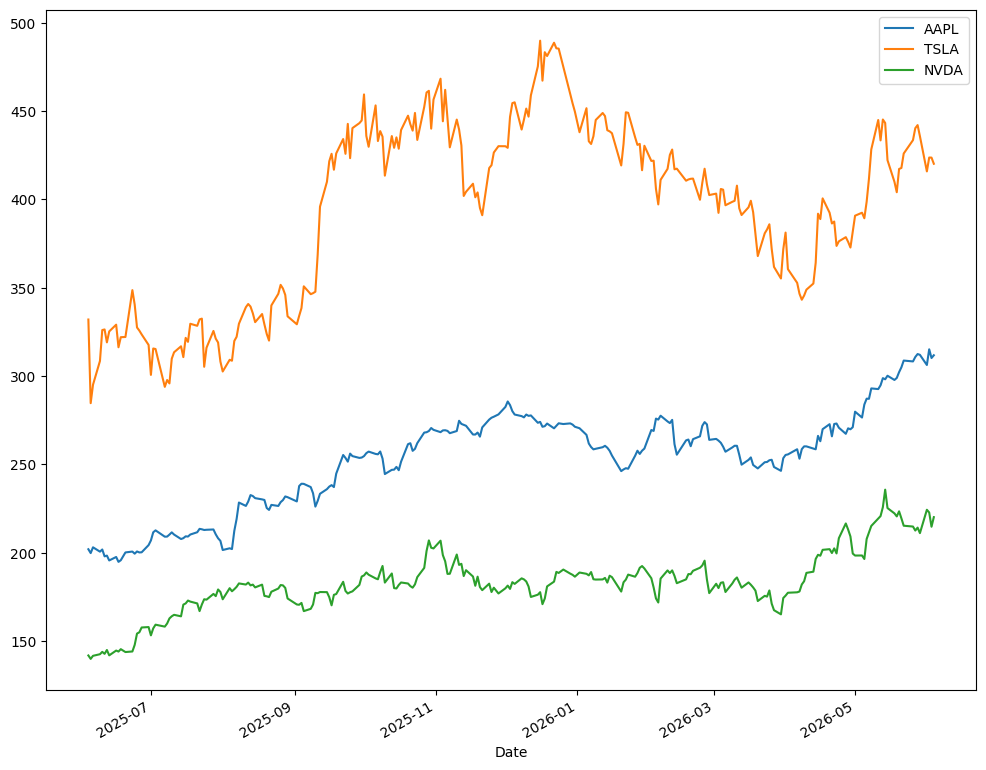

In [31]:
df = pd.DataFrame()

for i in range(len(company)):
  df[company[i]] = all_data[company[i]]['Close']

df.plot(figsize=(12,10))
plt.show()

Daily Return Formulae = (P_t - P_t-1)/ P_t-1

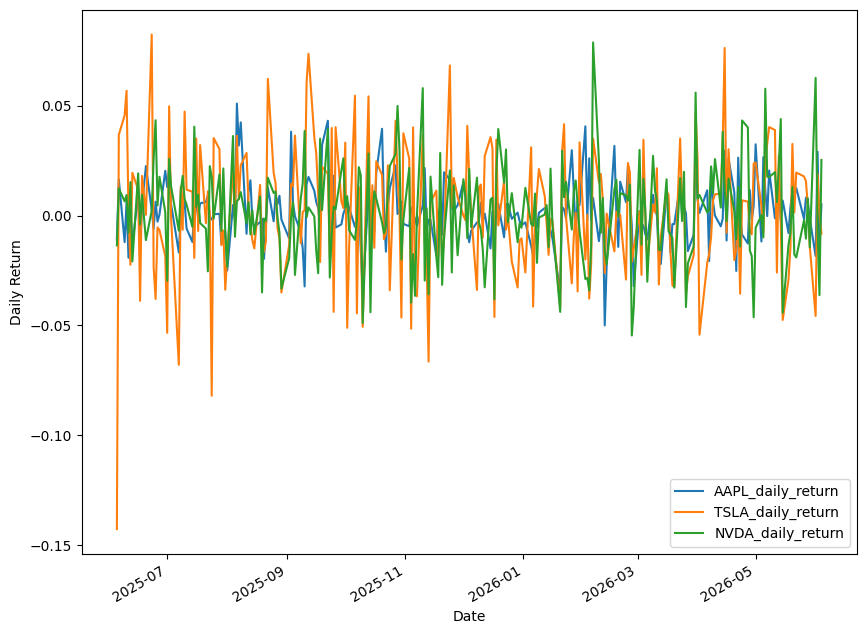

In [32]:
for i in range (len(company)):
  df[f'{company[i]}_daily_return'] =  all_data[company[i]]['Close'].pct_change()

df[['AAPL_daily_return','TSLA_daily_return','NVDA_daily_return']].plot(figsize=(10,8))
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.show()



Moving Average


<Axes: xlabel='Date'>

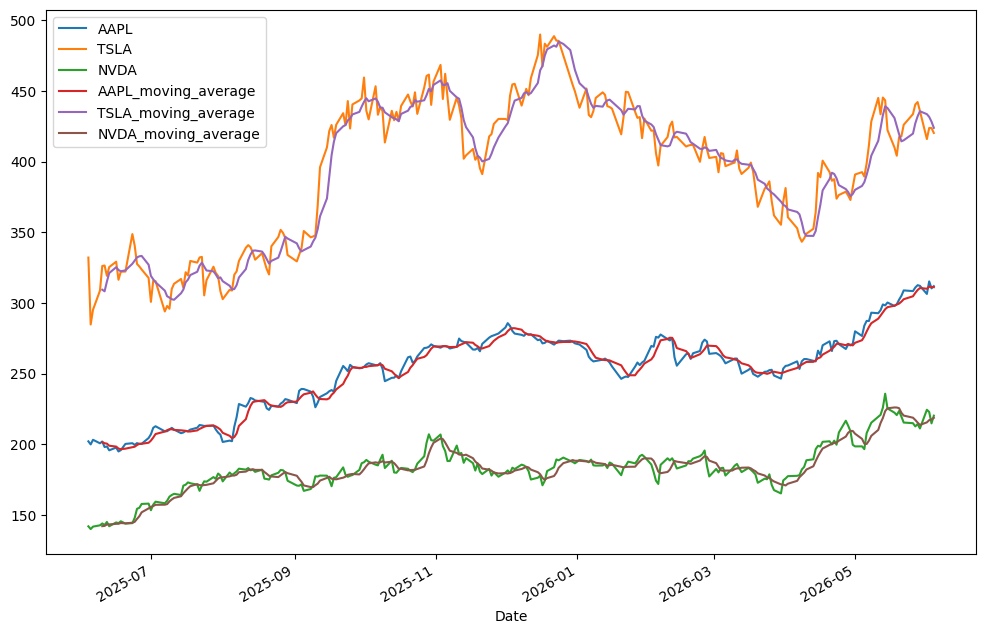

In [33]:
for i in range(len(company)):
  df[f"{company[i]}_moving_average"] = df[company[i]].rolling(window=5).mean()

df[['AAPL','TSLA','NVDA','AAPL_moving_average','TSLA_moving_average','NVDA_moving_average']].plot(figsize=(12,8))




Volatility

<Axes: xlabel='Date'>

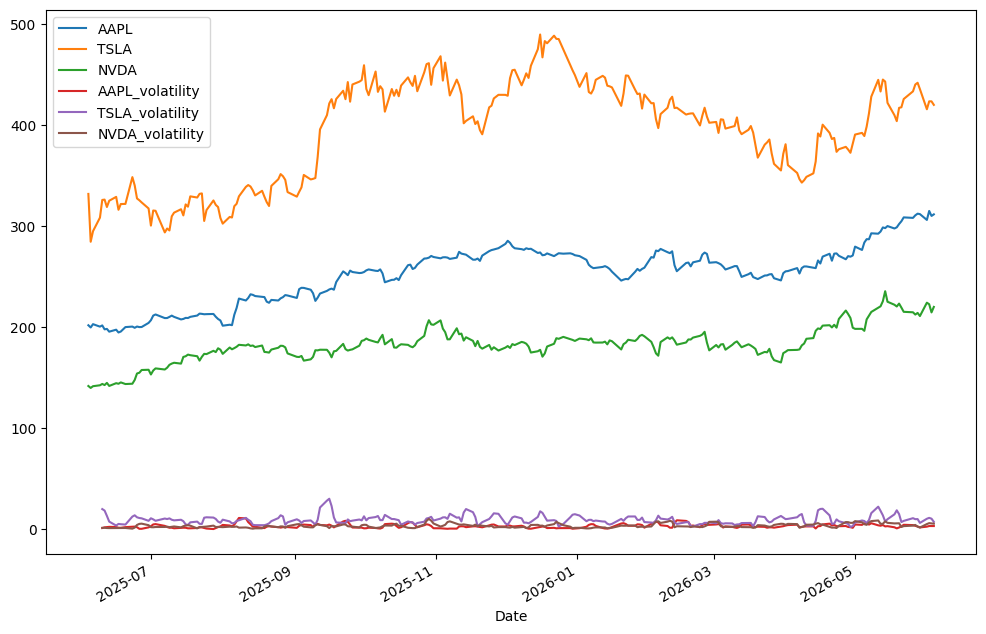

In [34]:
for i in range(len(company)):
  df[f"{company[i]}_volatility"] = df[company[i]].rolling(window=5).std()

df[['AAPL','TSLA','NVDA','AAPL_volatility','TSLA_volatility','NVDA_volatility']].plot(figsize=(12,8))



In [35]:
print(df['AAPL_volatility'].mean())
print(df['TSLA_volatility'].mean())
print(df['NVDA_volatility'].mean())

3.143484537843292
9.497395732464714
3.5042719293934472


AS WE CAN SEE THAT TESLA HAS THE HIGHEST VOLATILITY FOLLOWED BY NVIDIA AND THE LAST IS APPLE WITH THE LOWEST OUT OF THE 3. THIS SHOWS THAT APPLE IS A SAFER STOCK TO INVEST IN RIGHT NOW FOR INVESTORS LOOKING FOR LOW VOLATILE OPTIONS.

NOW SHALL LOOK INTO CUMPROD

In [36]:
apple_cumulative_returns = (1+df['AAPL_daily_return']).cumprod()
tesla_cumulative_returns = (1+df['TSLA_daily_return']).cumprod()
nvidia_cumulative_returns = (1+df['NVDA_daily_return']).cumprod()

print(apple_cumulative_returns[-1])
print(tesla_cumulative_returns[-1])
print(nvidia_cumulative_returns[-1])

1.5435215060037437
1.2655172768742666
1.5518029552157862


/tmp/ipykernel_13371/2552868024.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(apple_cumulative_returns[-1])
/tmp/ipykernel_13371/2552868024.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(tesla_cumulative_returns[-1])
/tmp/ipykernel_13371/2552868024.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(nvidia_cumulative_returns[-1])


In [37]:
summary = pd.DataFrame ({
    'Company':['Apple','Tesla','Nvidia'],
    'Average Daily Return':[df['AAPL_daily_return'].mean(),df['TSLA_daily_return'].mean(),df['NVDA_daily_return'].mean()],
    'Volatility':[df['AAPL_volatility'].mean(),df['TSLA_volatility'].mean(),df['NVDA_volatility'].mean()],
    'Cumulative Returns':[apple_cumulative_returns[-1],tesla_cumulative_returns[-1],nvidia_cumulative_returns[-1]]
})

/tmp/ipykernel_13371/3687648386.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Cumulative Returns':[apple_cumulative_returns[-1],tesla_cumulative_returns[-1],nvidia_cumulative_returns[-1]]


In [38]:
summary

,Company,Average Daily Return,Volatility,Cumulative Returns
0,Apple,0.001829,3.143485,1.543522
1,Tesla,0.001366,9.497396,1.265517
2,Nvidia,0.001983,3.504272,1.551803


NOW WE SHALL MOVE ON FROM INDIVIDUAL STOCK ANALYSIS TO START TO MAKE A PORTFOLIO WITH THESE 3 STOCKS AND SEE THE PERFORMANCE.

In [39]:
returns = pd.DataFrame ()

returns['APPLE'] = df['AAPL_daily_return']
returns['TESLA'] = df['TSLA_daily_return']
returns['NVDA'] = df['NVDA_daily_return']

returns = returns.dropna()

In [40]:
returns

,APPLE,TESLA,NVDA
Date,,,
2025-06-05 00:00:00-04:00,-0.010798,-0.142599,-0.013599
2025-06-06 00:00:00-04:00,0.016398,0.036670,0.012358
2025-06-09 00:00:00-04:00,-0.012113,0.045538,0.006421
2025-06-10 00:00:00-04:00,0.006056,0.056744,0.009325
2025-06-11 00:00:00-04:00,-0.019194,0.001043,-0.007781
...,...,...,...
2026-05-29 00:00:00-04:00,-0.001440,-0.014273,-0.014516
2026-06-01 00:00:00-04:00,-0.018426,-0.045687,0.062612
2026-06-02 00:00:00-04:00,0.029023,0.018900,-0.006864


In [41]:
correlation = returns.corr()
print(correlation)

          APPLE     TESLA      NVDA
APPLE  1.000000  0.286407  0.194743
TESLA  0.286407  1.000000  0.325572
NVDA   0.194743  0.325572  1.000000


SINCE THE CORRELATION IS LOW, DEVELOPING A PORTFOLIO WILL BE BETTER FOR US.

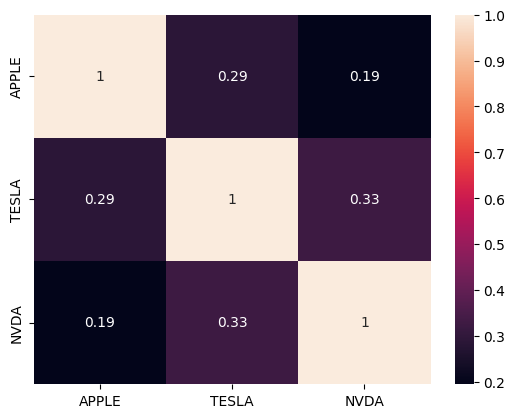

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(correlation,annot=True)
plt.show()

SO APPLE HAS A MID CORRELATION WITH TESLA AT 0.29 WHILE HAS A LOW CORRELATION WITH NVIDIA STOCK AT 0.19. LASTLY TESLA HAS THE HIGHEST CORRELATION WITH NVIDIA AT 0.33.

NOW MOVING ON WITH BUILDING AN ELEMENTARY PORTFOLIO WITH THESE 3 STOCKS.
FURTHER PORTFOLIO ANALYSIS SHALL BE CONDUCTED LIKE CALCULATING THE SHARPE RATIO, VOLATILITY ETC.

In [43]:
weights = [0.33,0.33,0.33]

portfolio_returns = (
    weights[0]*df['AAPL_daily_return']+ weights[1]*df['TSLA_daily_return']+ weights[2]*df['NVDA_daily_return']
)

In [44]:
portfolio_returns_volatility = portfolio_returns.std()

print(portfolio_returns_volatility)

0.015754329214048984


SO AS WE CAN SEE, WE HAVE ACHIEVED TO GET THE VOLATILITY DOWN INSTEAD OF HOLDING ONE WHICH WOULD HAVE BEEN ABOVE 1.

In [45]:
portfolio_returns

,0
Date,
2025-06-04 00:00:00-04:00,NaN
2025-06-05 00:00:00-04:00,-0.055109
2025-06-06 00:00:00-04:00,0.021591
2025-06-09 00:00:00-04:00,0.013149
2025-06-10 00:00:00-04:00,0.023801
...,...
2026-05-29 00:00:00-04:00,-0.009975
2026-06-01 00:00:00-04:00,-0.000495
2026-06-02 00:00:00-04:00,0.013549


WE SHALL BE USING THE PORTFOLIO RISK FORMULAE WHICH IS

$$
\sigma_p = \sqrt{w^T \Sigma w}
$$

1.4882079904491086


/tmp/ipykernel_13371/4293091100.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(portfolio_cumulative[-1])


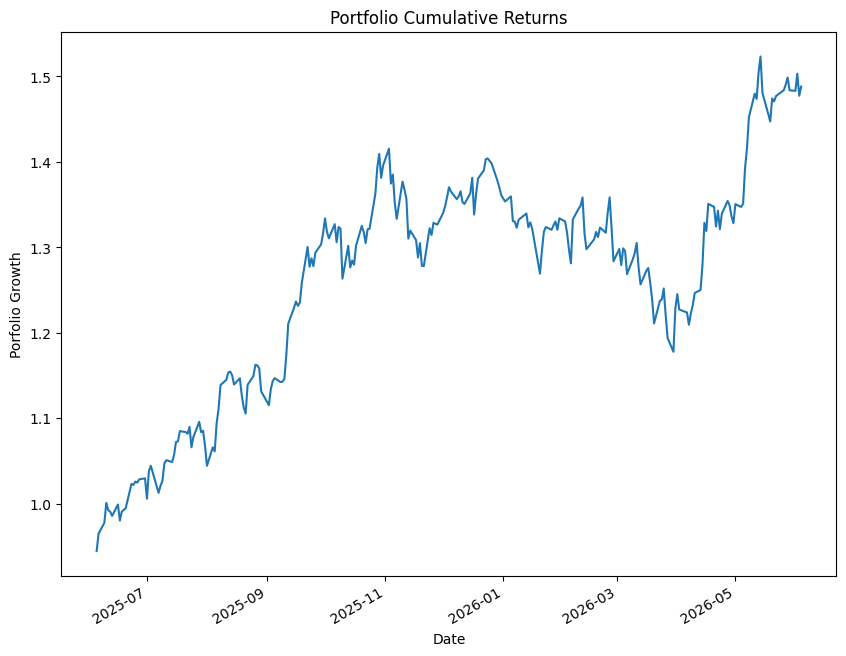

In [46]:
portfolio_cumulative = (1 + portfolio_returns).cumprod()

print(portfolio_cumulative[-1])
portfolio_cumulative.plot(figsize=(10,8))
plt.title('Portfolio Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Porfolio Growth')
plt.show()

THIS SHOWS THAT THE PORTFOLIO STILL PERFORMED RELATIVELY STRONG COMPARED TO INDIVIDUAL STOCKS. THIS ALSO SHOWS INVESTING IN A PORTFOLIO LIKE THIS HELPS US TO MANAGE RISK AND GET GOOD RETURNS.

SHARPE RATIO

$$
R_p-R_f/σ_p
$$

In [47]:
sharpe_ratio = portfolio_returns.mean()/ portfolio_returns_volatility
print(sharpe_ratio)

0.1084762001406142


SHARPE RATIO SHOWS POSITIVE RETURNS ACCOUNTING FOR THE RATE OF RISK. EVEN THOUGH TAKEN AS 0, WE SAW POSTIVE RETURNS.

* **CONCLUSION**

* **The equal-weight portfolio demonstrated moderate volatility with positive cumulative growth over the analyzed period. Diversification across Apple, Tesla, and Nvidia reduced overall portfolio risk relative to highly volatile individual equities. The positive Sharpe Ratio indicated favorable risk-adjusted performance.**

DAY 4 - We shall be working with CAPM and Beta Analysis

To further elaborate on that, I will define these concepts accordingly.

CAPM or Capital Asset Pricing Model is the estimated return based on the risk that the investor is taking. Since some stocks are more volatile than others, they expect higher returns in proportion to the risk.

CAPM oftens answer the question of "am i being compensated enough for the risk I am taking? "

The Formulae for calculating CAPM is:-
$$
E(R_i)=β(E(R_m)-R_f)
$$
Where
$$
E(R_i)=expectedreturnof the stock
$$
$$
β_i =  the beta of the stock
$$
$$
E(R_m) = the expected market return
$$
$$
R_f = the risk free rate
$$

Now Lets move on to beta.

Beta is a measure of the sensitivity a stock has relative to the market.

$$
β_i= Cov(R_i,R_m)/ Var(R_m)
$$

1) If the β =1 ,  then the stock moves with the market.

2) If the β > 1, then the stock is more volatile than the market.

3) If the β < 1 \, then it is relatively less volatile.

4) If the β < 0 , then it moves opposite to the market.


What this pricing model essentially does is give the investors an intersting insight of emphasizing systematic market risk.
Diversifying gets rid of the company based risk associated with individual stocks.
But market crashes affect everything.


In [48]:
spy = yf.Ticker('SPY')
market = spy.history(period='1y')


In [49]:
market['Returns'] = market['Close'].pct_change()


In [50]:
capm = pd.DataFrame({
    'Apple': df['AAPL_daily_return'],
    'Tesla': df['TSLA_daily_return'],
    'NVDA' : df['NVDA_daily_return'],
    'Market': market['Returns']
})

In [51]:
capm = capm.dropna()

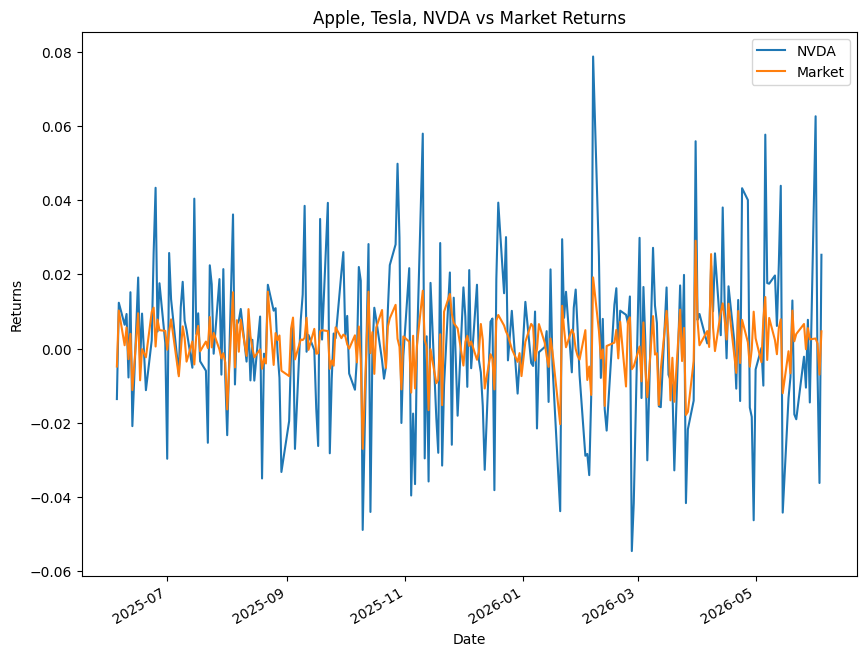

In [52]:
capm[['NVDA','Market']].plot(figsize=(10,8))
plt.title('Apple, Tesla, NVDA vs Market Returns')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.show()

In [53]:
apple_covariance = capm['Apple'].cov(capm['Market'])
tesla_covariance = capm.cov().iloc[1,3]
nvda_covariance = capm.cov().iloc[2,3]

market_variance = capm['Market'].var()

apple_beta =  apple_covariance/market_variance
tesla_beta =  tesla_covariance/market_variance
nvda_beta  =  nvda_covariance/ market_variance

In [54]:
print(apple_beta,tesla_beta,nvda_beta)

0.9550751995217219 2.047171008207178 1.8079348954304355


So to evaluate the beta values

Apple moves very closely with the market, if the market increases 1% then the stock increases 0.96%

For Tesla and Nvdia, they are more volatile than the market as if the market moves 1%, respective stocks move 2.05% and 1.8% respectively which is very volatile.


Now lets put it in the formualae and get the expected return

In [55]:
risk_free_rate = 0.04
market_return  = 0.10
apple_expected_return = risk_free_rate + apple_beta*(market_return - risk_free_rate)
tesla_expected_return = risk_free_rate + tesla_beta*(market_return - risk_free_rate)
nvdia_expected_return = risk_free_rate + nvda_beta*(market_return - risk_free_rate)


In [56]:
print('The expected return for apple after CAPM is', apple_expected_return)
print('The expected return for tesla after CAPM is', tesla_expected_return)
print('The expected return for nvdia after CAPM is', nvdia_expected_return)

The expected return for apple after CAPM is 0.09730451197130333
The expected return for tesla after CAPM is 0.16283026049243068
The expected return for nvdia after CAPM is 0.14847609372582615


The expected return is highest for tesla since investors expect the high return associated with high risk.
But the cumulative return shows that tesla had the lowest value out of the three.

Nvidia expected return was 14 percent and the cumulative return was relatively higher than tesla

Hence we can clearly state that the expected return does not translate equally or proportionally to realized return. There are a lot of variables to consider.

CAPM analysis indicated that Tesla and Nvidia required higher expected returns due to elevated systematic risk, as reflected in their high beta values. Apple demonstrated market-like behavior with a beta close to 1, resulting in expected returns aligned with broader market performance.

DAY 5

Running Monte Carlo Simulations on the stocks we are analysing right now.
So Monte Carlo Simulation calculates multiple possible future paths using randomness. It simulates multiple realistic possibilities

For this we have to introduce another concept called Geometric Brownian Motion (GBM)
This is a model that assumes prices involve continously, returns are random, stocks do no go negative and the volatility matters.
$$
dS_t​=μS_t​dt+σS_t​dW_t​
$$

Where $$ S_t $$ is the Stock Price, μ is the expected return (drift) and σ is the volatility and $$ dW_t $$ is the random market shock

The intuition behind this is the stock price depends on predictable growth component and the random shock component.


Estimated drift and volatility

In [58]:
mu = returns['NVDA'].mean()
sigma = returns['NVDA'].std()

print(mu,sigma)

0.001983499040952468 0.021585528422087028


Starting price is the last row in the dataset since that will be the most recent price which will be useful to us.

In [62]:
S0 = all_data['NVDA']['Close'].iloc[-1]

Defining Simulator Parameters

In [64]:
T = 252
dt = 1/T

simulations = 150

We need to generate random paths.

In [66]:
import numpy as np

prices = np.zeros((T,simulations))

prices[0] = S0

for i in range (1,T):
  Z= np.random.standard_normal(simulations)

  prices[i] = prices[i-1]*np.exp(
      (mu-0.5*sigma**2*dt)+ sigma*np.sqrt(dt)*Z
  )

Plotting the values

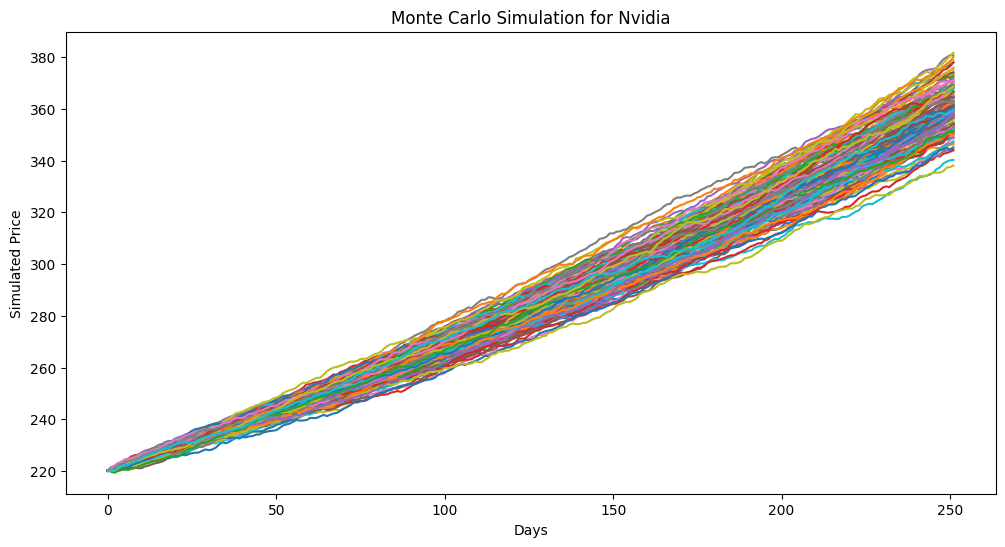

In [67]:
plt.figure(figsize=(12,6))

plt.plot(prices)

plt.title("Monte Carlo Simulation for Nvidia")

plt.xlabel("Days")

plt.ylabel("Simulated Price")

plt.show()

Expected Final Price

In [68]:
expected_final_price = prices[-1].mean()
print(expected_final_price)

360.6094279266955


In [69]:
print(prices[-1].min())
print(prices[-1].max())

338.0831303796678
381.6457221168365


DAY 5 DONE
Ran first Monte Carlo Simulaton using geometric brownian model for nvdia stock and shows that the stock may go from 338 to 381 after one year. Lets see xD